# **Ejercicios de esfuerzo y deformación**

En esta sesión estaremos resolviendo los ejercicios planteados en la sección 2.4 del libro Introducción a la Sismología de Pearson. En este notebook encontrarán los ejercicios que pueden ser resueltos a partir de la construcción de códigos en Python; hay otros ejercicios que consisten en demostraciones o en encontrar expresiones para ciertos parámetros en términos de otros parámetros, los cuales deberán resolver por su cuenta. Como comentó el profesor Carlos Vargas, la resolución de todos estos ejercicios contará como la Tarea #5, para la cual deberán entregar un notebook con el desarrollo de los ejercicios que se pueden computarizar y un documento adicional con el desarrollo de los demás ejercicios.

## **Ejercicio 1**

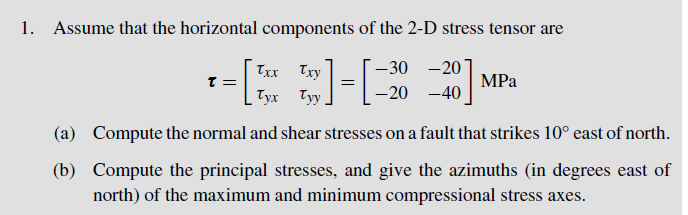

#### **a)**

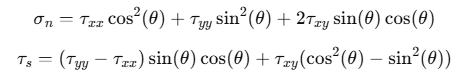

In [ ]:
import numpy as np

def calcular_esfuerzos(ang,tensor):
  #Paso 1: calcular los cosenos directores
  n = np.array([np.cos(np.deg2rad(ang)),np.sin(np.deg2rad(ang))])
  f = np.array([-np.sin(np.deg2rad(ang)),np.cos(np.deg2rad(ang))])

  #Paso 2: obtener el vector de tracción
  trac_nom = np.matmul(tensor,n)

  #Paso 3: obtener el valor del esfuerzo normal y de cizalla
  esf_nom = np.dot(trac_nom,n)
  esf_ciz = np.dot(trac_nom,f)

  return esf_nom, esf_ciz


ang1 = 10  #en grados
#ang2 = 45
tensor1 = np.array(([-30,-20],[-20,-40]))   #en MPa
#tensor2 = np.array(([-40,-10],[-10,-60]))
esf_nom, esf_ciz = calcular_esfuerzos(ang1,tensor1)

print("Esfuerzo normal = %4.1f MPa" %(esf_nom))
print("Esfuerzo de cizalla = %4.1f MPa" %(esf_ciz))

Esfuerzo normal = -37.1 MPa
Esfuerzo de cizalla = -20.5 MPa


#### **b)**

In [ ]:
#Paso 1: obtener los valores y vectores propios de la matriz
def valores_vectores_propios(matriz):
  valores, vectores = np.linalg.eig(matriz)
  return valores, vectores

valores, vectores = valores_vectores_propios(tensor1)
print(valores)
print(vectores)
print("Esfuerzo mayor = %4.1f MPa" %(valores[1]))
print("Esfuerzo menor = %4.1f MPa" %(valores[0]))

#Paso 2: determinación de los ángulos de los esfuerzos máximo y mínimo compresional
ang_mayor = np.rad2deg(np.arctan2(vectores[1,1],vectores[0,1]))
ang_menor = np.rad2deg(np.arctan2(vectores[1,0],vectores[0,0]))
print("Ángulo esfuerzo mayor = %4.1f°" %(ang_mayor))
print("Ángulo esfuerzo menor = %4.1f°" %(ang_menor))

[-14.38447187 -55.61552813]
[[ 0.78820544  0.61541221]
 [-0.61541221  0.78820544]]
Esfuerzo mayor = -55.6 MPa
Esfuerzo menor = -14.4 MPa
Ángulo esfuerzo mayor = 52.0°
Ángulo esfuerzo menor = -38.0°


## **Ejercicio 2**

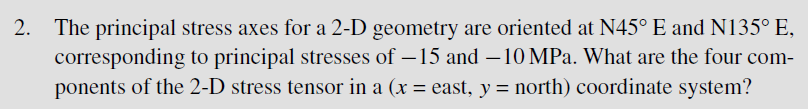

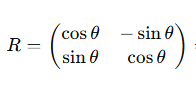

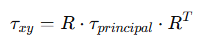

In [ ]:
def calcular_componentes_rotacion(tensor,ang_rotacion):
  R = np.array([[np.cos(np.deg2rad(ang_rotacion)),-np.sin(np.deg2rad(ang_rotacion))],[np.sin(np.deg2rad(ang_rotacion)),np.cos(np.deg2rad(ang_rotacion))]])
  Rt = np.transpose(R)
  M = np.matmul(R,tensor)
  Tr = np.matmul(M,Rt)
  return Tr

valores2 = [-15,-10]
tensor3 = np.diag(valores2)
ang_rotacion = 45
coordenadas = calcular_componentes_rotacion(tensor3,ang_rotacion)
print(coordenadas)

[[-12.5  -2.5]
 [ -2.5 -12.5]]


## **Ejercicio 3**

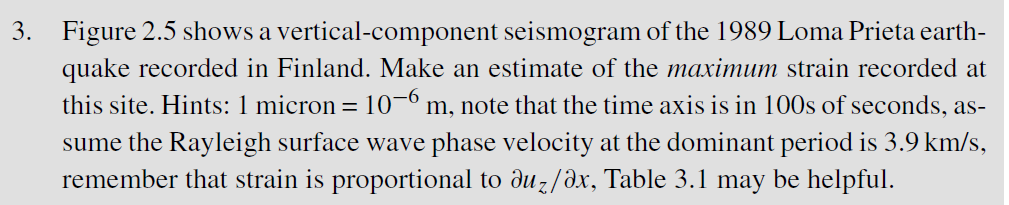

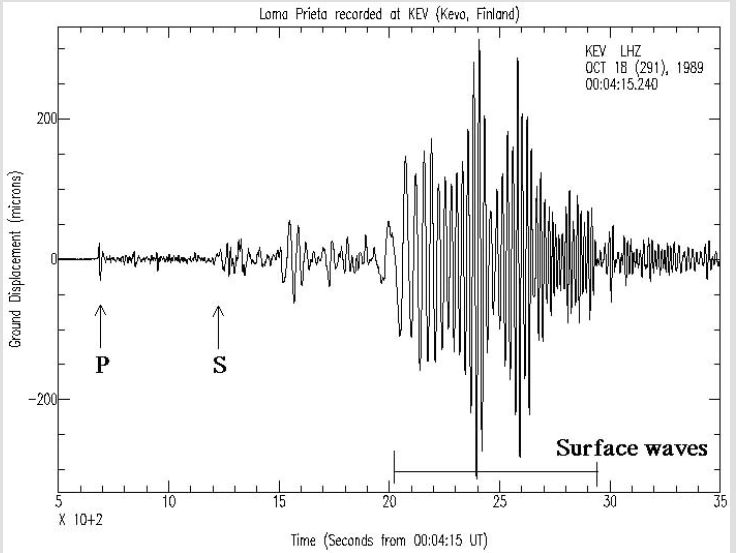

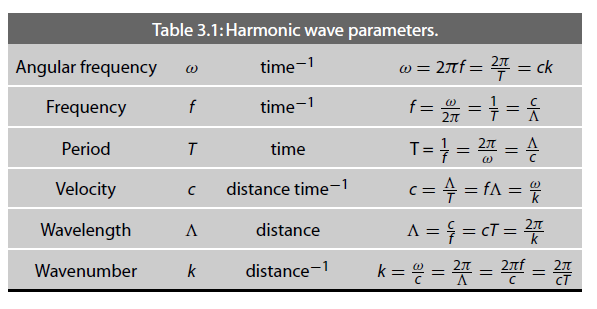

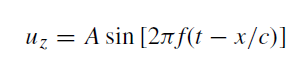
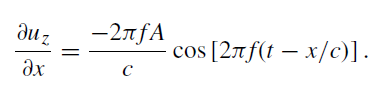
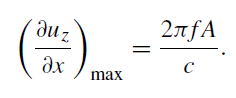

In [ ]:
# Función para calcular la deformación máxima
def calcular_deformacion_maxima(desplazamiento_max, velocidad, duracion_total, num_ciclos):
    periodo = duracion_total / num_ciclos  # Calcular el período (T)
    deformacion = (2 * np.pi * desplazamiento_max) / (velocidad * periodo)
    return deformacion

# Valores de entrada
desplazamiento_max = 300e-6  # Desplazamiento máximo en metros (300 micrones)
velocidad = 3900              # Velocidad de fase en m/s (3.9 km/s)
duracion_total = (29.3-20.2)*100          # Duración total en segundos (de 20.2 a 29.3 en 100s de segundos)
num_ciclos = 38               # Número de ciclos observados en el sismograma

# Calcular la deformación máxima
deformacion_maxima = calcular_deformacion_maxima(desplazamiento_max, velocidad, duracion_total, num_ciclos)
print(f"La deformación máxima es: {deformacion_maxima:.2e}")

La deformación máxima es: 2.02e-08


Ejercicio 7

In [8]:
import sympy as sp
sigma = sp.Symbol('sigma')
ratio = sp.Symbol('alpha_beta')
eq = ((ratio**2 - 2) / (2 * ratio**2 - 2)) - sigma
sigma1 = float(input("Ingrese el valor de sigma: "))
soluciones = sp.solve(eq.subs(sigma, sigma1), ratio)
print("El ratio de la velocidad de la onda p sobre la velocidad de la onda s para una roca con un poisson de 0.30 es:",soluciones[1])

Ingrese el valor de sigma: 0.30
El ratio de la velocidad de la onda p sobre la velocidad de la onda s para una roca con un poisson de 0.30 es: 1.87082869338697


Ejercicio 8

In [12]:
def ejercicio (Vp, Densi):
  a = (((Vp)**2)*Densi)//3 #parametros de lame
  return (a)
#datos ejercicio
Vp = 5500
p = 2600
#desarrollo
b = ejercicio(Vp,p)
Bulk = (5*b)/3
Young = (5*b)/2
print(f"Los parametros de Posisson son: {b : .2e}Pa")
print(f"Los parametros de Bulk es: {Bulk: .2e}Pa")
print(f"Los parametros de Young es: {Young : .2e}Pa")
#comprobacion a mano en el pdf

Los parametros de Posisson son:  2.62e+10Pa
Los parametros de Bulk es:  4.37e+10Pa
Los parametros de Young es:  6.55e+10Pa


Ejercicio 9

In [13]:
from tabulate import tabulate

def bulk(densidad, Vp, Vs):
    a = densidad * ((Vp**2) - (4 * (Vs**2) // 3))
    return a

datosejercicio = [["CMB (arriba)",2871, 5560, 13710, 7260, bulk(5560, 13710, 7260)],["CMB (abajo)",2981, 9900, 8060, 0, bulk(9900, 8060, 0)],
    ["ICB (arriba)",5071, 12120, 10310, 0, bulk(12120, 10310, 0)],["ICB (abajo)",5149.5, 12760, 11030, 3500, bulk(12760, 11030, 3500)],
]
for j in datosejercicio:
  j[5] = f"{j[5]:.2e}"
headers = ["Límite","Profundidad(Km)", "Densidad (kg/m³)", "Vp (m/s)", "Vs (m/s)", "K (Pa)"]

print(tabulate(datosejercicio, headers=headers, tablefmt="--"))

Límite          Profundidad(Km)    Densidad (kg/m³)    Vp (m/s)    Vs (m/s)    K (Pa)
------------  -----------------  ------------------  ----------  ----------  --------
CMB (arriba)             2871                  5560       13710        7260  6.54e+11
CMB (abajo)              2981                  9900        8060           0  6.43e+11
ICB (arriba)             5071                 12120       10310           0  1.29e+12
ICB (abajo)              5149.5               12760       11030        3500  1.34e+12


Ejercicio 10

In [18]:
import numpy as np
tasa_cambio = -0.28
factor_x = (tasa_cambio * 0.001) / 1000
def mostrar_matriz(matriz):
    np.set_printoptions(suppress=False, formatter={'float': '{:.2e}'.format})
    print(np.array(matriz))
def modificar_tensor(esfuerzo_corte, matriz):
    for i in range(len(matriz)):
        for j in range(len(matriz)):
            matriz[i][j] = (2 * esfuerzo_corte * matriz[i][j])
    return matriz
def modificar_tensor_con_tiempo(years, matriz, esfuerzo_corte):
    for i in range(len(matriz)):
        for j in range(len(matriz)):
            matriz[i][j] = (2 * esfuerzo_corte * years * matriz[i][j])
    return matriz
tensor_deformacion = [[0, factor_x], [factor_x, 0]]
tensor_deformacion_1 = [[0, factor_x], [factor_x, 0]]
tensor_deformacion_2 = [[0, factor_x], [factor_x, 0]]
tensor_rotacion = [[0, -factor_x], [-factor_x, 0]]
modulo_corte = 27e9
tiempo = 200
tensor_cambio = modificar_tensor(modulo_corte, tensor_deformacion_1)
tensor_cambio_tiempo = modificar_tensor_con_tiempo(tiempo, tensor_deformacion_2, modulo_corte)
print("Tensor de Deformación por año")
mostrar_matriz(np.array(tensor_deformacion))
print("")
print("Tensor de rotacion por año")
mostrar_matriz(np.array(tensor_rotacion))
print("")
print("Cambio Tensor con 27GPa")
mostrar_matriz(np.array(tensor_cambio))
print("")
print("Cambio Tensor con 200 años")
mostrar_matriz(np.array(tensor_cambio_tiempo))


Tensor de Deformación por año
[[0.00e+00 -2.80e-07]
 [-2.80e-07 0.00e+00]]

Tensor de rotacion por año
[[0.00e+00 2.80e-07]
 [2.80e-07 0.00e+00]]

Cambio Tensor con 27GPa
[[0.00e+00 -1.51e+04]
 [-1.51e+04 0.00e+00]]

Cambio Tensor con 200 años
[[0.00e+00 -3.02e+06]
 [-3.02e+06 0.00e+00]]
